# K-Means Clustering Data Polutan Udara

Notebook ini melakukan clustering pada hasil ekstraksi **68 fitur TSFEL** untuk **CO, NO2, dan SO2**.

Analisis dilakukan **terpisah untuk setiap polutan**, tanpa menggabungkan ketiga polutan.

Setiap polutan diuji dalam dua kondisi:
1. Tanpa PCA: 68 fitur => K-Means.
2. Dengan PCA: 68 fitur => 37 komponen PCA => K-Means.

Untuk setiap kondisi, K diuji dari **2 sampai 10** menggunakan Elbow Method dan Silhouette Score.


## 1. Library dan Konfigurasi

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FILE_POLUTAN = {
    "CO": "ekstraksi_fitur_co.csv",
    "NO2": "ekstraksi_fitur_no2.csv",
    "SO2": "ekstraksi_fitur_so2.csv"
}

KOLOM_IDENTITAS = ["id", "nama", "daerah"]
K_RANGE = range(2, 11)

# Sesuai skenario tugas/referensi
N_DIMENSI_PCA = 37

RANDOM_STATE = 42
N_INIT = 10


## 2. Membaca dan Memeriksa Dataset

Masing-masing file dibaca secara terpisah. Kolom `id`, `nama`, dan `daerah` merupakan identitas sehingga tidak digunakan sebagai fitur clustering.


In [20]:
data_polutan = {}

for polutan, nama_file in FILE_POLUTAN.items():
    df = pd.read_csv(nama_file)
    fitur = [c for c in df.columns if c not in KOLOM_IDENTITAS]

    print(f"\n{polutan}")
    print(f"File         : {nama_file}")
    print(f"Jumlah baris : {df.shape[0]}")
    print(f"Jumlah fitur : {len(fitur)}")

    data_polutan[polutan] = {"df": df, "fitur": fitur}



CO
File         : ekstraksi_fitur_co.csv
Jumlah baris : 37
Jumlah fitur : 68

NO2
File         : ekstraksi_fitur_no2.csv
Jumlah baris : 37
Jumlah fitur : 68

SO2
File         : ekstraksi_fitur_so2.csv
Jumlah baris : 37
Jumlah fitur : 68


## 3. Preprocessing

Fitur dikonversi menjadi numerik, baris dengan nilai kosong pada fitur dihapus, kemudian dilakukan standardisasi menggunakan `StandardScaler`.


In [21]:
def siapkan_data(df, fitur):
    data = df.copy()
    data[fitur] = data[fitur].apply(pd.to_numeric, errors="coerce")
    data = data.dropna(subset=fitur).copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data[fitur])

    return data, X_scaled


## 4. Evaluasi K-Means

Untuk K=2 sampai K=10 dihitung:
- **Inertia** untuk Elbow Method.
- **Silhouette Score** untuk mengevaluasi kualitas cluster.

K dengan Silhouette Score tertinggi digunakan sebagai K terbaik.


In [22]:
def evaluasi_kmeans(X):
    hasil = []

    for k in K_RANGE:
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT
        )
        label = model.fit_predict(X)

        hasil.append({
            "K": k,
            "Inertia": model.inertia_,
            "Silhouette Score": silhouette_score(X, label)
        })

    return pd.DataFrame(hasil)


## 5. Visualisasi Elbow dan Silhouette

In [23]:
def plot_evaluasi(hasil, judul):
    plt.figure(figsize=(9, 5))
    plt.plot(hasil["K"], hasil["Inertia"], marker="o")
    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method - {judul}")
    plt.xticks(list(K_RANGE))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(hasil["K"], hasil["Silhouette Score"], marker="o")
    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Score - {judul}")
    plt.xticks(list(K_RANGE))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# 6. Eksperimen Clustering per Polutan

Setiap polutan memiliki empat skenario:
1. 68 fitur tanpa PCA, K=2–10.
2. 37 komponen PCA, K=2–10.

Dengan demikian, CO, NO2, dan SO2 tetap dianalisis secara terpisah.


POLUTAN: CO

CO - TANPA PCA
Jumlah fitur: 68


,K,Inertia,Silhouette Score
0,2,1123.800303,0.795494
1,3,660.214101,0.697034
2,4,509.373825,0.342517
3,5,413.889526,0.184501
4,6,361.351576,0.153812
5,7,315.868398,0.161337
6,8,272.854136,0.142490
7,9,239.322559,0.150055
8,10,221.039012,0.145469


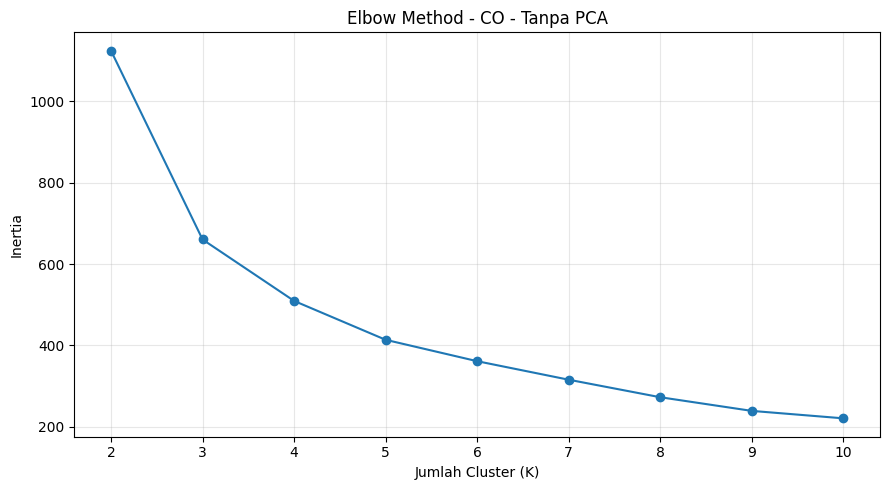

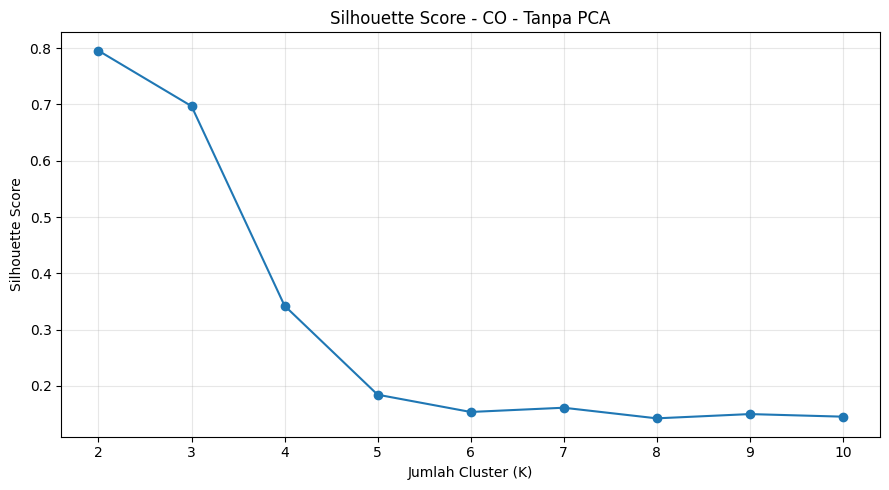


CO - DENGAN PCA
Jumlah fitur awal : 68
Jumlah komponen   : 37
Explained variance: 1.000000


,K,Inertia,Silhouette Score
0,2,1123.800303,0.795494
1,3,660.214101,0.697034
2,4,509.373825,0.342517
3,5,413.889526,0.184501
4,6,361.351576,0.153812
5,7,315.868398,0.161337
6,8,272.854136,0.142490
7,9,239.322559,0.150055
8,10,221.039012,0.145469


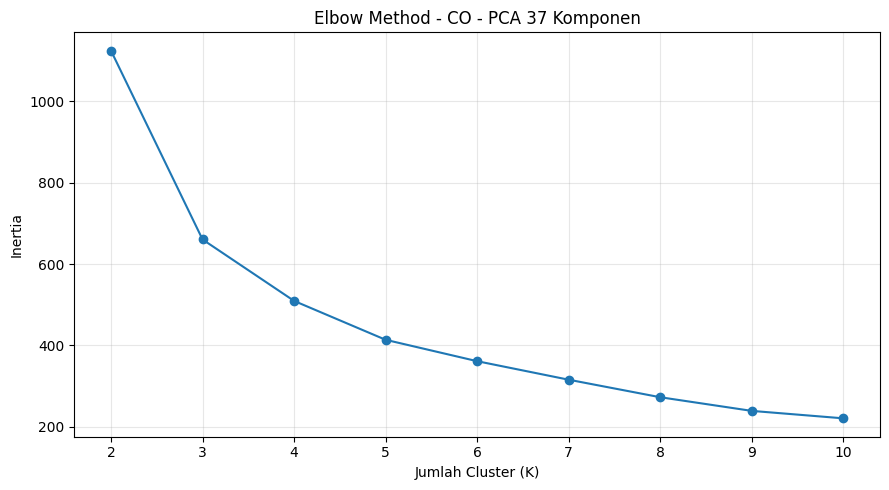

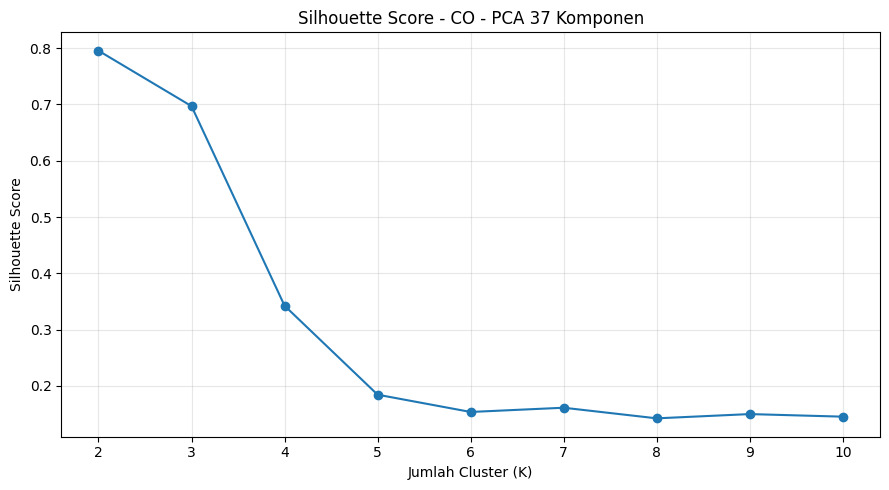

POLUTAN: NO2

NO2 - TANPA PCA
Jumlah fitur: 68


,K,Inertia,Silhouette Score
0,2,1326.578705,0.745489
1,3,1001.281921,0.190722
2,4,811.798641,0.204530
3,5,655.789824,0.216606
4,6,578.312417,0.185596
5,7,504.989692,0.161947
6,8,458.598752,0.166889
7,9,424.658844,0.151594
8,10,373.027966,0.172124


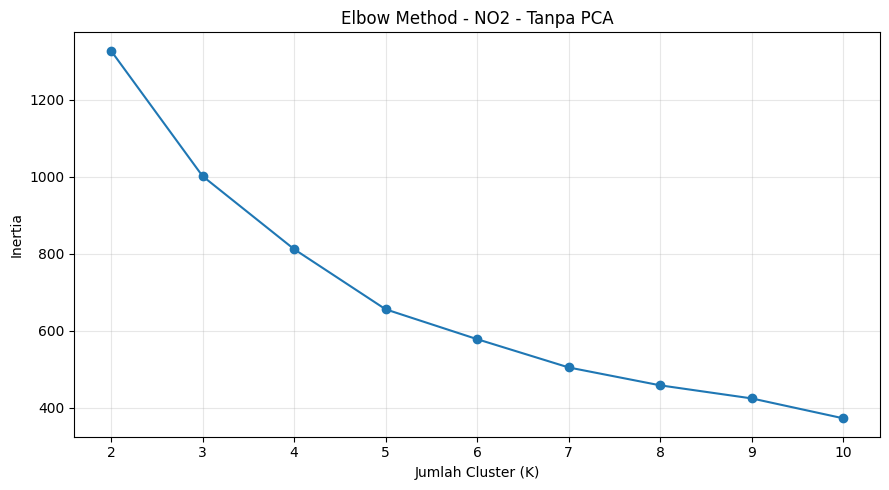

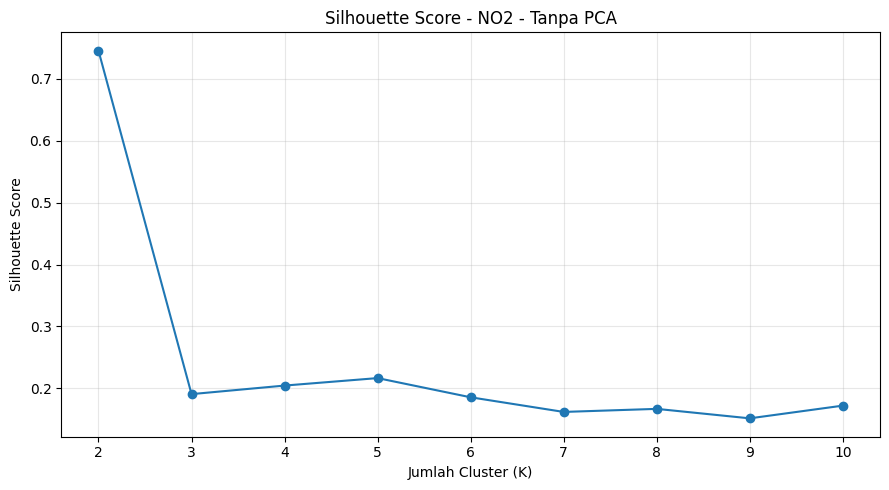


NO2 - DENGAN PCA
Jumlah fitur awal : 68
Jumlah komponen   : 37
Explained variance: 1.000000


,K,Inertia,Silhouette Score
0,2,1326.578705,0.745489
1,3,1001.281921,0.190722
2,4,811.798641,0.204530
3,5,655.789824,0.216606
4,6,578.312417,0.185596
5,7,504.989692,0.161947
6,8,458.598752,0.166889
7,9,424.658844,0.151594
8,10,373.027966,0.172124


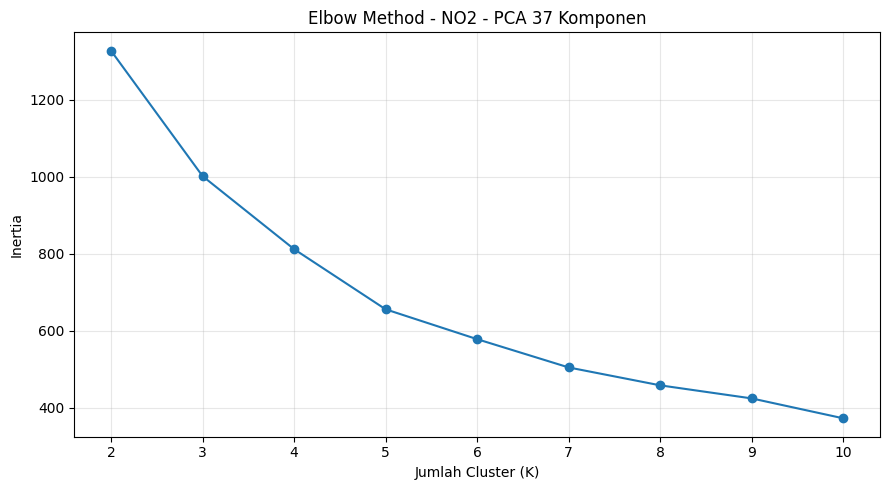

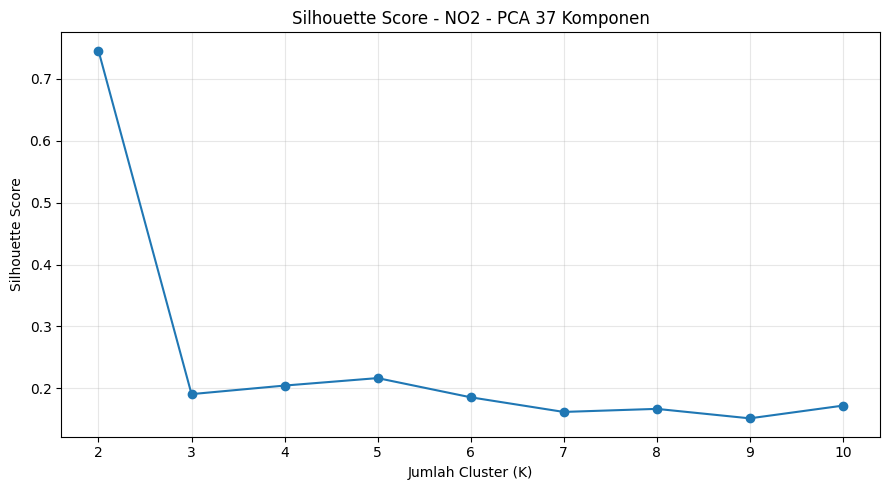

POLUTAN: SO2

SO2 - TANPA PCA
Jumlah fitur: 68


,K,Inertia,Silhouette Score
0,2,1210.459866,0.789366
1,3,691.644801,0.708469
2,4,525.289021,0.392088
3,5,413.678733,0.406057
4,6,335.555572,0.135855
5,7,301.063844,0.126801
6,8,267.415808,0.099564
7,9,239.817616,0.120845
8,10,230.171524,0.092438


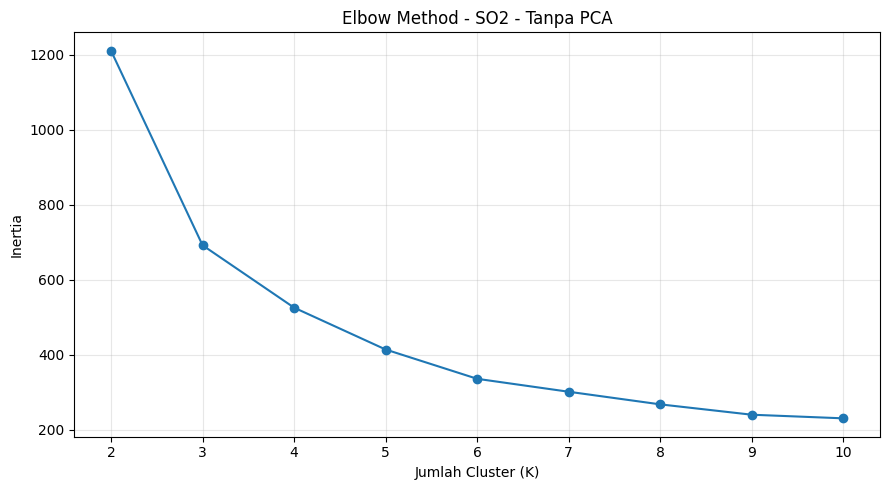

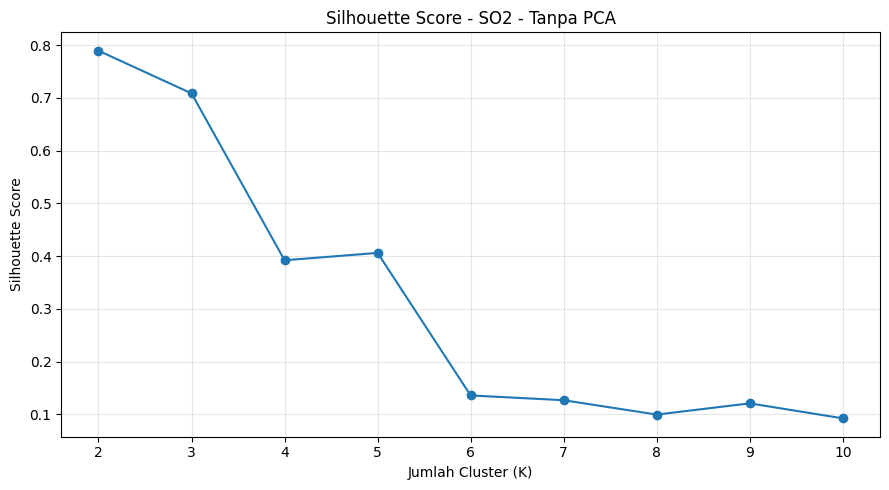


SO2 - DENGAN PCA
Jumlah fitur awal : 68
Jumlah komponen   : 37
Explained variance: 1.000000


,K,Inertia,Silhouette Score
0,2,1210.459866,0.789366
1,3,691.644801,0.708469
2,4,525.289021,0.392088
3,5,413.678733,0.406057
4,6,335.555572,0.135855
5,7,301.063844,0.126801
6,8,267.415808,0.099564
7,9,239.817616,0.120845
8,10,230.171524,0.092438


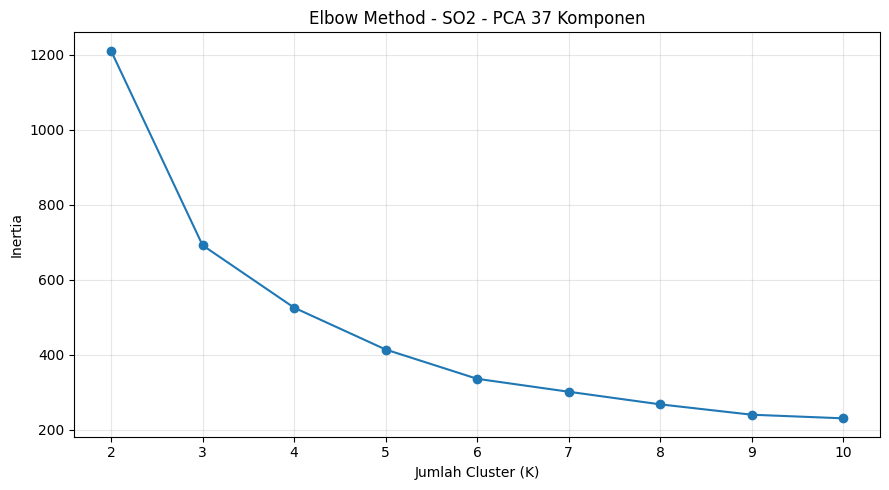

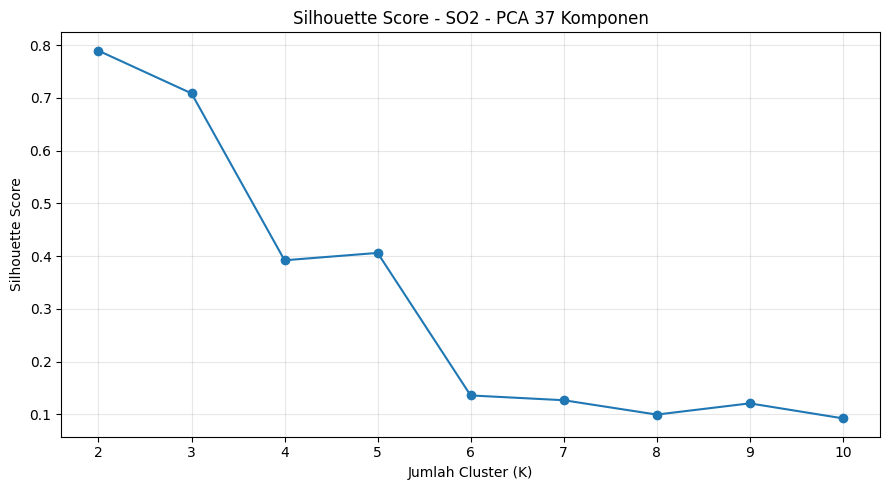

In [24]:
hasil_semua = {}

for polutan, info in data_polutan.items():
    print(f"POLUTAN: {polutan}")

    data, X_scaled = siapkan_data(info["df"], info["fitur"])

    # -------------------------
    # Tanpa PCA
    # -------------------------
    hasil_no_pca = evaluasi_kmeans(X_scaled)

    print(f"\n{polutan} - TANPA PCA")
    print(f"Jumlah fitur: {X_scaled.shape[1]}")
    display(hasil_no_pca)
    plot_evaluasi(hasil_no_pca, f"{polutan} - Tanpa PCA")

    k_no_pca = int(
        hasil_no_pca.loc[
            hasil_no_pca["Silhouette Score"].idxmax(), "K"
        ]
    )

    # -------------------------
    # Dengan PCA
    # -------------------------
    pca = PCA(
        n_components=N_DIMENSI_PCA,
        random_state=RANDOM_STATE
    )
    X_pca = pca.fit_transform(X_scaled)

    hasil_pca = evaluasi_kmeans(X_pca)

    print(f"\n{polutan} - DENGAN PCA")
    print(f"Jumlah fitur awal : {X_scaled.shape[1]}")
    print(f"Jumlah komponen   : {X_pca.shape[1]}")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.6f}")
    display(hasil_pca)
    plot_evaluasi(hasil_pca, f"{polutan} - PCA {N_DIMENSI_PCA} Komponen")

    k_pca = int(
        hasil_pca.loc[
            hasil_pca["Silhouette Score"].idxmax(), "K"
        ]
    )

    hasil_semua[polutan] = {
        "data": data,
        "X_scaled": X_scaled,
        "X_pca": X_pca,
        "pca_model": pca,
        "hasil_no_pca": hasil_no_pca,
        "hasil_pca": hasil_pca,
        "k_no_pca": k_no_pca,
        "k_pca": k_pca
    }


## 7. Ringkasan K Terbaik

In [25]:
ringkasan = []

for polutan, hasil in hasil_semua.items():
    h1 = hasil["hasil_no_pca"]
    h2 = hasil["hasil_pca"]

    r1 = h1.loc[h1["Silhouette Score"].idxmax()]
    r2 = h2.loc[h2["Silhouette Score"].idxmax()]

    ringkasan.extend([
        {
            "Polutan": polutan,
            "Kondisi": "Tanpa PCA",
            "Jumlah Fitur": hasil["X_scaled"].shape[1],
            "K Terbaik": int(r1["K"]),
            "Silhouette Score": float(r1["Silhouette Score"])
        },
        {
            "Polutan": polutan,
            "Kondisi": "Dengan PCA",
            "Jumlah Fitur": hasil["X_pca"].shape[1],
            "K Terbaik": int(r2["K"]),
            "Silhouette Score": float(r2["Silhouette Score"])
        }
    ])

ringkasan = pd.DataFrame(ringkasan)
display(ringkasan)


,Polutan,Kondisi,Jumlah Fitur,K Terbaik,Silhouette Score
0,CO,Tanpa PCA,68,2,0.795494
1,CO,Dengan PCA,37,2,0.795494
2,NO2,Tanpa PCA,68,2,0.745489
3,NO2,Dengan PCA,37,2,0.745489
4,SO2,Tanpa PCA,68,2,0.789366
5,SO2,Dengan PCA,37,2,0.789366


## 8. K-Means Final dan Distribusi Cluster

K-Means dijalankan kembali menggunakan K terbaik yang diperoleh dari Silhouette Score.


In [26]:
hasil_final = {}

for polutan, hasil in hasil_semua.items():
    data = hasil["data"].copy()

    # Tanpa PCA
    model_no_pca = KMeans(
        n_clusters=hasil["k_no_pca"],
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    data_no_pca = data.copy()
    data_no_pca["cluster"] = model_no_pca.fit_predict(hasil["X_scaled"])
    data_no_pca["cluster_label"] = (
        "cluster_" + data_no_pca["cluster"].astype(str)
    )

    # Dengan PCA
    model_pca = KMeans(
        n_clusters=hasil["k_pca"],
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    data_pca = data.copy()
    data_pca["cluster"] = model_pca.fit_predict(hasil["X_pca"])
    data_pca["cluster_label"] = (
        "cluster_" + data_pca["cluster"].astype(str)
    )

    hasil_final[polutan] = {
        "tanpa_pca": data_no_pca,
        "dengan_pca": data_pca
    }

    print(f"\n{polutan} - Tanpa PCA - K={hasil['k_no_pca']}")
    display(data_no_pca["cluster_label"].value_counts().sort_index())

    print(f"{polutan} - Dengan PCA - K={hasil['k_pca']}")
    display(data_pca["cluster_label"].value_counts().sort_index())



CO - Tanpa PCA - K=2


,count
cluster_label,
cluster_0,36
cluster_1,1


CO - Dengan PCA - K=2


,count
cluster_label,
cluster_0,36
cluster_1,1



NO2 - Tanpa PCA - K=2


...

,count
cluster_label,
cluster_0,36
cluster_1,1



SO2 - Tanpa PCA - K=2


,count
cluster_label,
cluster_0,36
cluster_1,1


SO2 - Dengan PCA - K=2


,count
cluster_label,
cluster_0,36
cluster_1,1


## 9. Scatter Plot Cluster Berdasarkan Nama

Sumbu X menunjukkan nama data/area dan sumbu Y menunjukkan cluster. Plot ini digunakan untuk melihat persebaran anggota cluster.


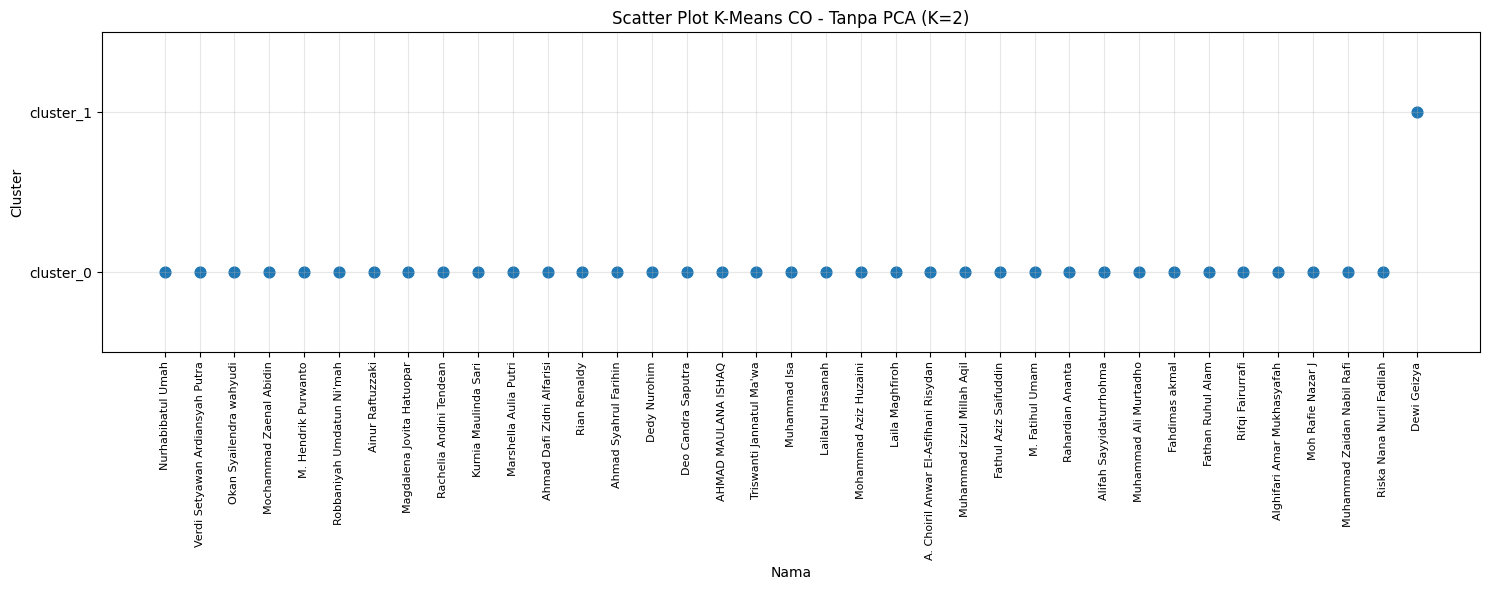

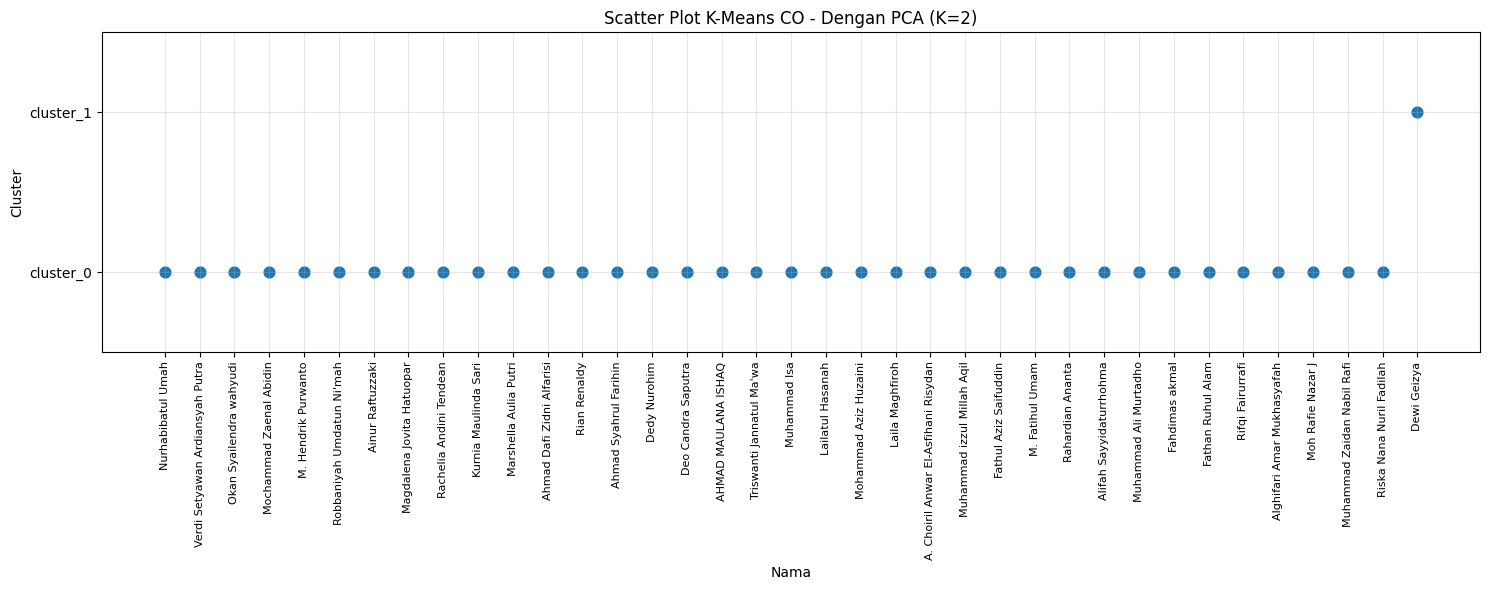

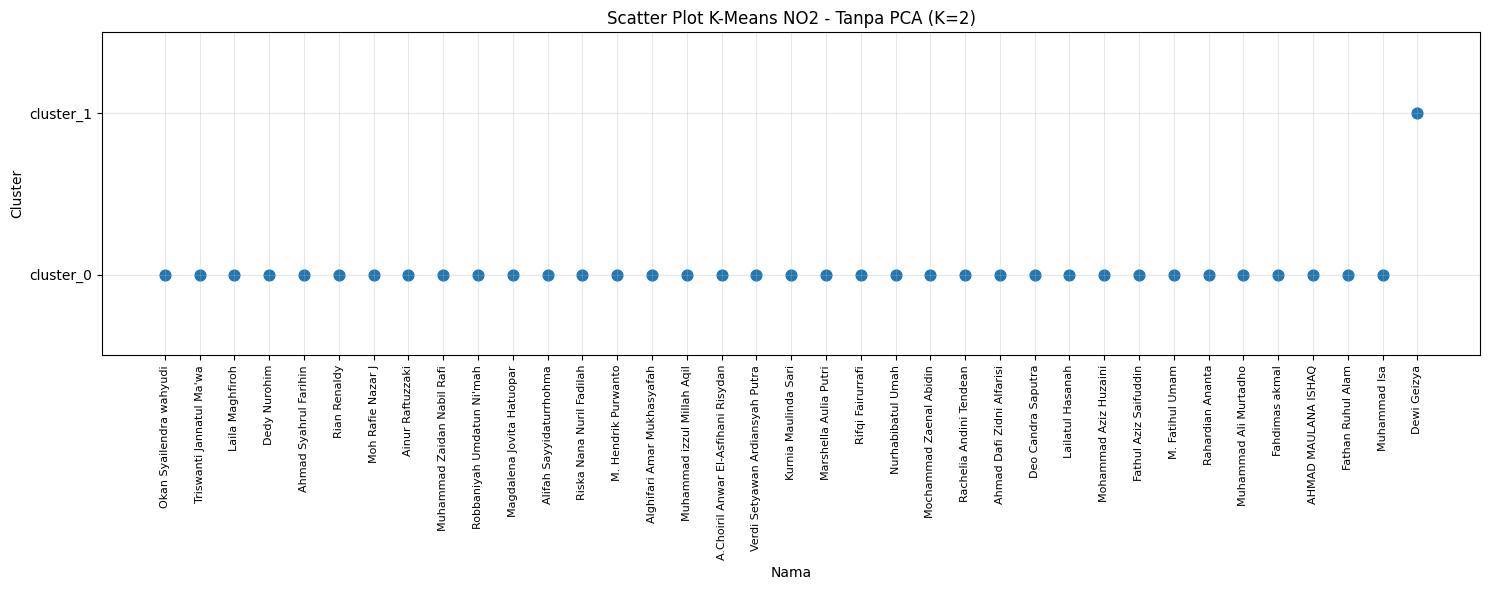

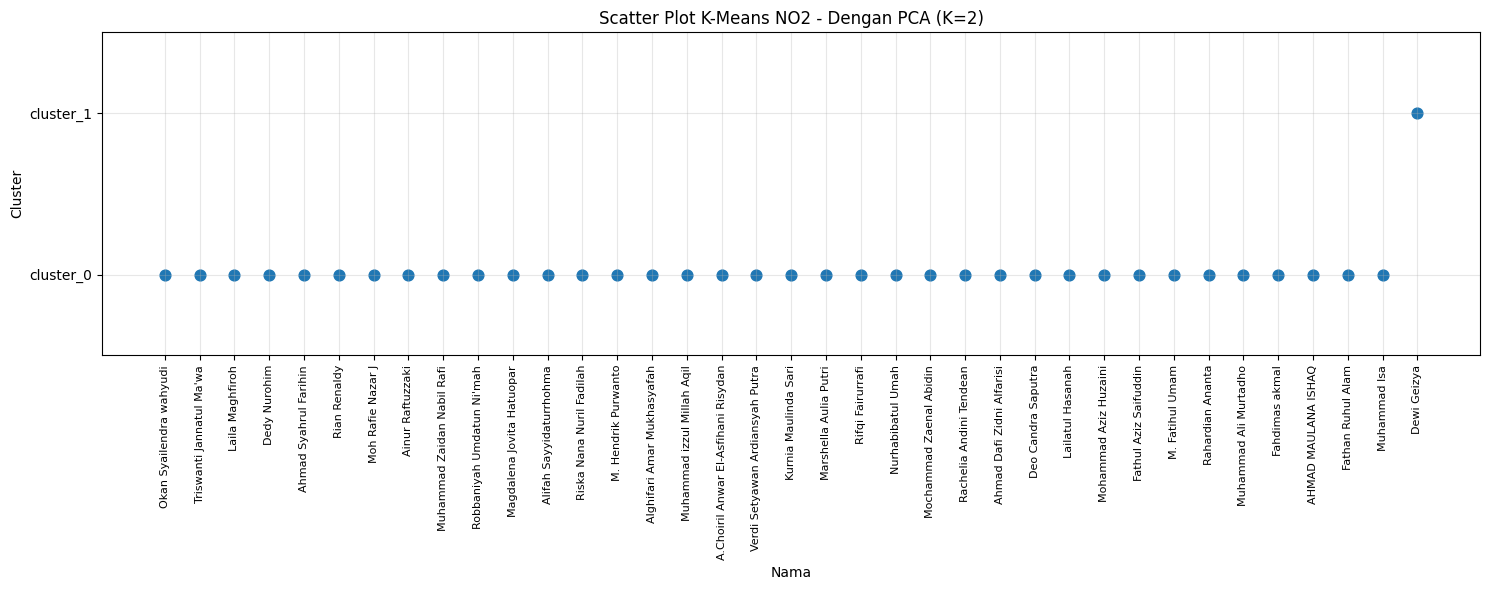

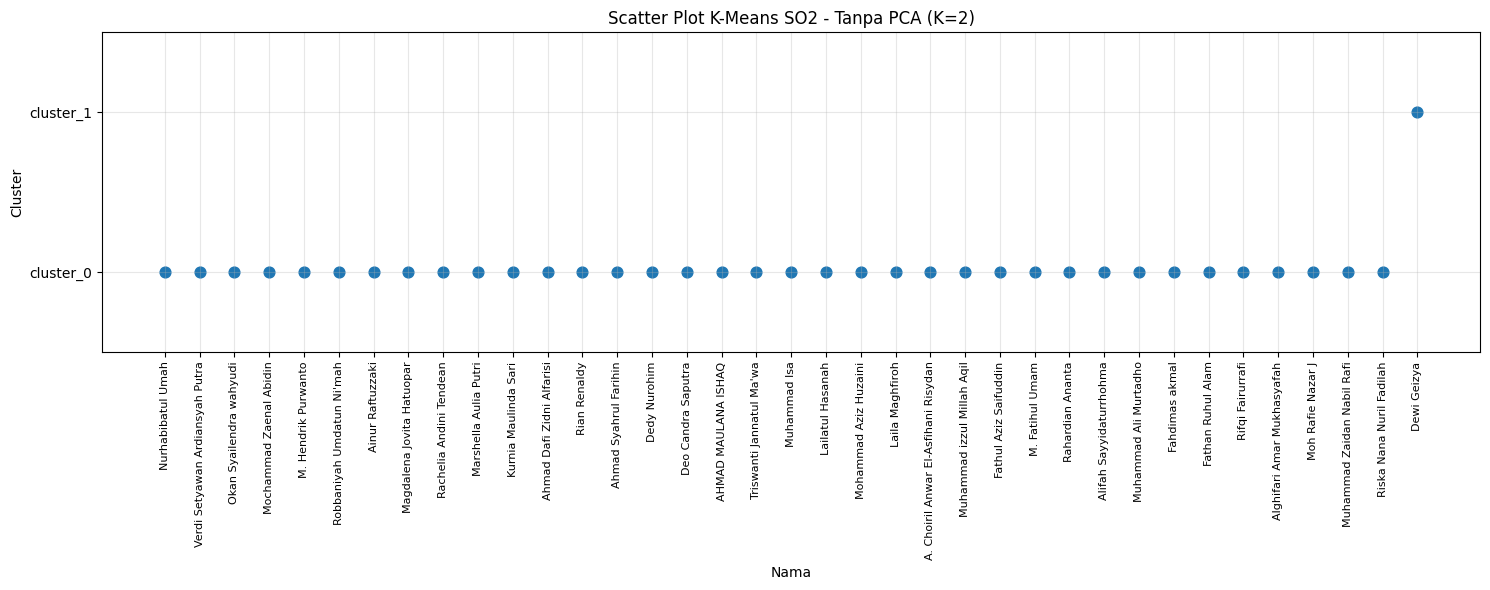

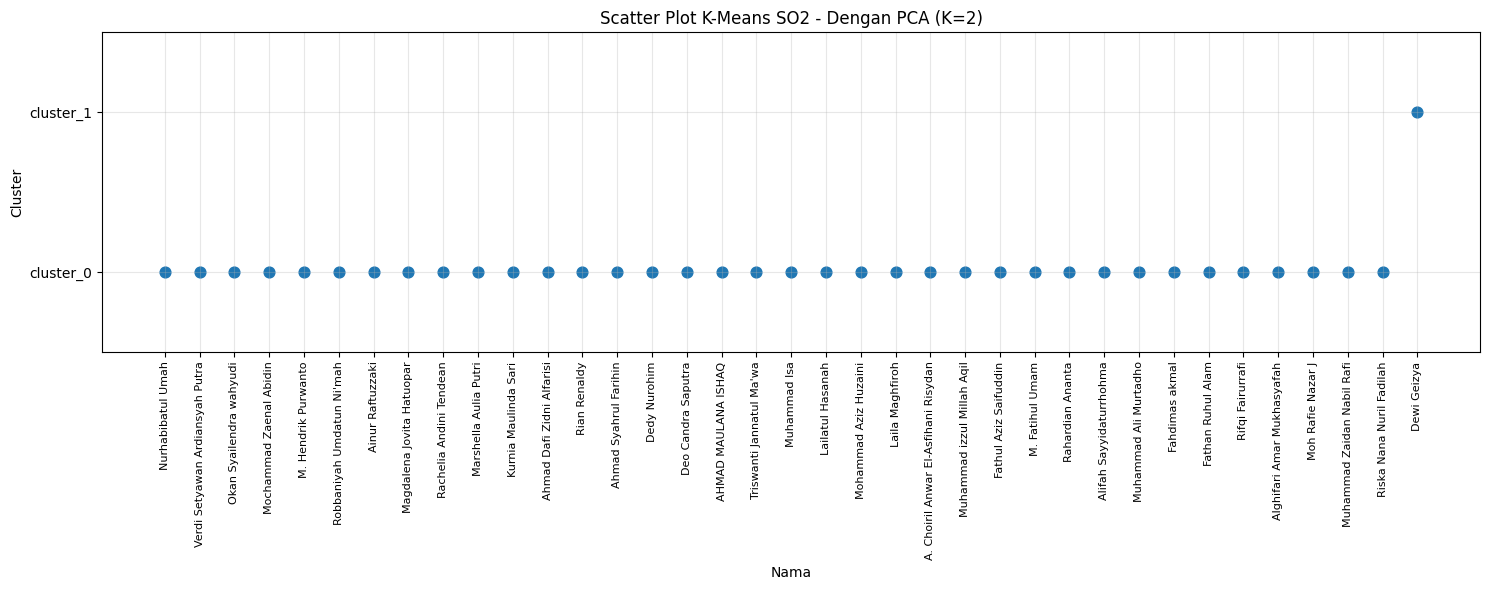

In [27]:
def plot_cluster(data, k, judul):
    x = range(len(data))
    y = data["cluster"]

    plt.figure(figsize=(15, 6))
    plt.scatter(x, y, s=60)

    plt.xticks(
        x,
        data["nama"].astype(str),
        rotation=90,
        fontsize=8
    )
    plt.yticks(
        range(k),
        [f"cluster_{i}" for i in range(k)]
    )

    plt.ylim(-0.5, k - 0.5)
    plt.xlabel("Nama")
    plt.ylabel("Cluster")
    plt.title(judul)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


for polutan, hasil in hasil_semua.items():

    k1 = hasil["k_no_pca"]
    plot_cluster(
        hasil_final[polutan]["tanpa_pca"],
        k1,
        f"Scatter Plot K-Means {polutan} - Tanpa PCA (K={k1})"
    )

    k2 = hasil["k_pca"]
    plot_cluster(
        hasil_final[polutan]["dengan_pca"],
        k2,
        f"Scatter Plot K-Means {polutan} - Dengan PCA (K={k2})"
    )


## 10. Profil Daerah per Cluster

In [30]:
for polutan, hasil in hasil_final.items():

    for kondisi, data in hasil.items():
        print(f"{polutan} - {kondisi}")

        profil = (
            data.groupby(
                ["cluster_label", "daerah"],
                dropna=False
            )
            .size()
            .reset_index(name="Jumlah")
            .sort_values(
                ["cluster_label", "Jumlah"],
                ascending=[True, False]
            )
        )

        display(profil)


CO - tanpa_pca


,cluster_label,daerah,Jumlah
7,cluster_0,"Kamal, Bangkalan",2
15,cluster_0,"Kwanyar, Bangkalan",2
0,cluster_0,"Asemrowo, Surabaya",1
1,cluster_0,"Bandung, Jogoroto, Jombang",1
2,cluster_0,"Banyu Ajuh, Perumnas, Kamal",1
3,cluster_0,Baron Nganjuk,1
4,cluster_0,"Cerme, Gresik",1
5,cluster_0,"Dukun, Gresik",1
6,cluster_0,"Gresik Kota, Gresik",1
8,cluster_0,"Kec. Bangkalan, Kab. Bangkalan",1


CO - dengan_pca


,cluster_label,daerah,Jumlah
7,cluster_0,"Kamal, Bangkalan",2
15,cluster_0,"Kwanyar, Bangkalan",2
0,cluster_0,"Asemrowo, Surabaya",1
1,cluster_0,"Bandung, Jogoroto, Jombang",1
2,cluster_0,"Banyu Ajuh, Perumnas, Kamal",1
3,cluster_0,Baron Nganjuk,1
4,cluster_0,"Cerme, Gresik",1
5,cluster_0,"Dukun, Gresik",1
6,cluster_0,"Gresik Kota, Gresik",1
8,cluster_0,"Kec. Bangkalan, Kab. Bangkalan",1


NO2 - tanpa_pca


...

,cluster_label,daerah,Jumlah
8,cluster_0,"Kamal, Bangkalan",2
15,cluster_0,"Kwanyar, Bangkalan",2
0,cluster_0,"Asemrowo, Surabaya",1
1,cluster_0,"Bandung, Jogoroto, Jombang",1
2,cluster_0,"Bangkalan Kota,Bangkalan",1
3,cluster_0,"Banyu Ajuh, Perumnas, Kamal",1
4,cluster_0,Baron Nganjuk,1
5,cluster_0,"Cerme, Gresik",1
6,cluster_0,"Dukun, Gresik",1
7,cluster_0,"Gresik Kota, Gresik",1


SO2 - tanpa_pca


,cluster_label,daerah,Jumlah
7,cluster_0,"Kamal, Bangkalan",2
15,cluster_0,"Kwanyar, Bangkalan",2
0,cluster_0,"Asemrowo, Surabaya",1
1,cluster_0,"Bandung, Jogoroto, Jombang",1
2,cluster_0,"Banyu Ajuh, Perumnas, Kamal",1
3,cluster_0,Baron Nganjuk,1
4,cluster_0,"Cerme, Gresik",1
5,cluster_0,"Dukun, Gresik",1
6,cluster_0,"Gresik Kota, Gresik",1
8,cluster_0,"Kec. Bangkalan, Kab. Bangkalan",1


SO2 - dengan_pca


,cluster_label,daerah,Jumlah
7,cluster_0,"Kamal, Bangkalan",2
15,cluster_0,"Kwanyar, Bangkalan",2
0,cluster_0,"Asemrowo, Surabaya",1
1,cluster_0,"Bandung, Jogoroto, Jombang",1
2,cluster_0,"Banyu Ajuh, Perumnas, Kamal",1
3,cluster_0,Baron Nganjuk,1
4,cluster_0,"Cerme, Gresik",1
5,cluster_0,"Dukun, Gresik",1
6,cluster_0,"Gresik Kota, Gresik",1
8,cluster_0,"Kec. Bangkalan, Kab. Bangkalan",1


## 11. Perbandingan Hasil

Tabel ini digunakan untuk membandingkan hasil clustering tanpa PCA dan dengan PCA pada masing-masing polutan.

Interpretasi akhir harus menggunakan **hasil aktual notebook**, terutama K terbaik, Silhouette Score, dan distribusi anggota cluster.


In [29]:

for polutan in ringkasan["Polutan"].unique():
    print(f"\n{polutan}")
    display(
        ringkasan[ringkasan["Polutan"] == polutan]
    )



CO


,Polutan,Kondisi,Jumlah Fitur,K Terbaik,Silhouette Score
0,CO,Tanpa PCA,68,2,0.795494
1,CO,Dengan PCA,37,2,0.795494



NO2


,Polutan,Kondisi,Jumlah Fitur,K Terbaik,Silhouette Score
2,NO2,Tanpa PCA,68,2,0.745489
3,NO2,Dengan PCA,37,2,0.745489



SO2


,Polutan,Kondisi,Jumlah Fitur,K Terbaik,Silhouette Score
4,SO2,Tanpa PCA,68,2,0.789366
5,SO2,Dengan PCA,37,2,0.789366


## 12. Implementasi K-Means Clustering Menggunakan KNIME

Implementasi clustering dilakukan menggunakan KNIME dengan alur pengolahan data yang terdiri dari pembacaan data PostgreSQL, normalisasi, reduksi dimensi menggunakan PCA, dan proses K-Means Clustering. Analisis dilakukan secara terpisah pada masing-masing polutan, yaitu CO, NO₂, dan SO₂.

### 1. Alur Pengolahan Data

Data polutan yang telah melalui proses ekstraksi fitur TSFEL dimasukkan ke dalam KNIME melalui PostgreSQL. Data kemudian dinormalisasi menggunakan metode Z-Score agar setiap fitur memiliki skala yang sebanding sebelum dilakukan proses clustering.

Untuk membandingkan pengaruh reduksi dimensi, clustering dilakukan dalam dua kondisi, yaitu:
- **Tanpa PCA**, menggunakan 68 fitur TSFEL.
- **Dengan PCA**, menggunakan hasil reduksi dimensi menjadi 37 komponen utama.

Proses K-Means kemudian diterapkan pada masing-masing kondisi untuk memperoleh kelompok data berdasarkan karakteristik fitur polutan.

![](https://cdn.mathpix.com/snip/images/KpTDajANURTo09zjKOjE1BOc34CKsay2okd6N8Cmetw.original.fullsize.png)


### 2. Clustering Tanpa PCA

Pada proses tanpa PCA, seluruh 68 fitur hasil ekstraksi TSFEL digunakan sebagai input K-Means. Proses ini dilakukan secara terpisah untuk polutan CO, NO₂, dan SO₂.

Hasil clustering kemudian divisualisasikan menggunakan Scatter Plot untuk melihat persebaran data berdasarkan dua fitur yang dipilih sebagai sumbu visualisasi.

**Gambar X. Scatter Plot CO Tanpa PCA**

![](https://cdn.mathpix.com/snip/images/XeYY9QWGfAHeNDK42JXVZVFTqBVtGqhITYQulhWnw7A.original.fullsize.png)

**Gambar X. Scatter Plot NO₂ Tanpa PCA**

![](https://cdn.mathpix.com/snip/images/k0AgXZH3bmKZ8FXH8a3MK7clZtHz6dvnkmH4Z9-gS58.original.fullsize.png)

**Gambar X. Scatter Plot SO₂ Tanpa PCA**

![](https://cdn.mathpix.com/snip/images/ATnBqg13t2rE5BGD30WXNtGBTrzvp5BKNV5FQ9WZj0w.original.fullsize.png)

### 3. Clustering dengan PCA

Pada proses dengan PCA, 68 fitur TSFEL direduksi menjadi 37 komponen utama. Hasil PCA selanjutnya digunakan sebagai input K-Means untuk masing-masing polutan.

Reduksi dimensi dilakukan untuk memperoleh representasi data dengan jumlah fitur yang lebih sedikit, kemudian hasil clustering divisualisasikan menggunakan Scatter Plot.

**Gambar X. Scatter Plot CO dengan PCA**

![](https://cdn.mathpix.com/snip/images/gW-TfNKpziD9cW-mcQj84cOy4pJgqI1ZdOIwNOxeHSs.original.fullsize.png)

**Gambar X. Scatter Plot NO₂ dengan PCA**

![](https://cdn.mathpix.com/snip/images/abClMWmzqMLcOmPVHGS3SMZphPwfYTTXyB7FiSs0blI.original.fullsize.png)

**Gambar X. Scatter Plot SO₂ dengan PCA**

![](https://cdn.mathpix.com/snip/images/RfszGyIUrmD3WkdSMI8FNRxwwn4RvRFb8qhugTMXzvw.original.fullsize.png)

### 4. Hasil Implementasi

Berdasarkan implementasi pada KNIME, proses clustering dilakukan pada tiga polutan dengan dua kondisi, yaitu tanpa PCA dan dengan PCA. Dengan demikian, diperoleh enam hasil clustering yang selanjutnya digunakan untuk membandingkan pola pengelompokan data sebelum dan sesudah reduksi dimensi.

Hasil Scatter Plot digunakan sebagai visualisasi pendukung untuk melihat persebaran data dan pembentukan cluster pada masing-masing kondisi.

## 12. Kesimpulan

Berdasarkan hasil clustering menggunakan K-Means pada polutan CO, NO₂, dan SO₂, diperoleh hasil pengelompokan pada kondisi tanpa PCA dan dengan PCA. PCA mereduksi 68 fitur menjadi 37 komponen utama, sehingga jumlah dimensi data lebih rendah. Perbandingan Silhouette Score dan distribusi anggota cluster digunakan untuk melihat perubahan hasil clustering setelah reduksi dimensi. Cluster dengan jumlah anggota yang sedikit perlu diperhatikan dalam interpretasi karena memiliki karakteristik yang berbeda dari kelompok lainnya.